### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

             IndivID  PopID        Pop Country Continent  sex    lat   long  \
Chipewyan29     2012    811  Chipewyan  Canada   AMERICA    0  59.55 -107.3   
Chipewyan31     2156    811  Chipewyan  Canada   AMERICA    0  59.55 -107.3   
Chipewyan33     2381    811  Chipewyan  Canada   AMERICA    0  59.55 -107.3   
Chipewyan35     2382    811  Chipewyan  Canada   AMERICA    0  59.55 -107.3   
Chipewyan37     2383    811  Chipewyan  Canada   AMERICA    0  59.55 -107.3   
...              ...    ...        ...     ...       ...  ...    ...    ...   
Pima1043        1057     87       Pima  Mexico   AMERICA    0  29.00 -108.0   
Pima1045        1058     87       Pima  Mexico   AMERICA    0  29.00 -108.0   
Pima1047        1059     87       Pima  Mexico   AMERICA    0  29.00 -108.0   
Pima1049        1060     87       Pima  Mexico   AMERICA    0  29.00 -108.0   
Pima1051        1061     87       Pima  Mexico   AMERICA    0  29.00 -108.0   

             L1.125  L1.130  ...  L677.259  L677.26

/tmp/ipykernel_17958/4177909619.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


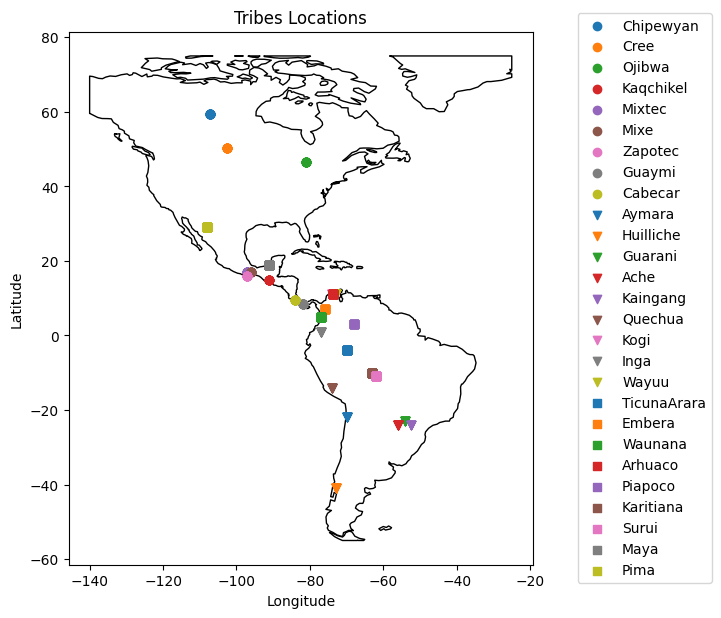

In [4]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))
print(gdf)

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

The code loads the data, then extracts the longitude, latitude and the tribe columns of the data loaded.

Then, it creates a geodataframe (data frame with geometric coordinates assigned to each row) with the original dataframe.

Then, it plots the map, and finally, it loops for each tribe in the geodataframe and it assigns a different marker and color to each tribe, and plots that marker in the correct coordinates.

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [6]:
import numpy as np

y = df["long"]
X = df.drop(columns=["IndivID","PopID","Pop","Country","Continent","sex","lat","long"])

n, p = X.shape
XTX = X.T @ X
XTX_inv = np.linalg.solve(XTX, np.eye(p))
beta_hat = XTX_inv @ X.T @ y

(5709, 5709)


LinAlgError: Singular matrix

We run into the error "Singular Matrix" in the line where we use np.linalg.solve. This is caused because np.linalg.solve computes the exact solution, however this is only possible if the matrix is well-determined. Here it is not the case since $\text{rank}(X) < p$. So, np.linalg.solve is trying to solve a problem with no solution, and this is why it raises an error.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [7]:
n, p = X.shape
XTX = X.T @ X
XTX_inv = np.linalg.lstsq(XTX, np.eye(p))
beta_hat = XTX_inv[0] @ X.T @ y
print(beta_hat)

0      -0.040058
1      -0.019409
2       0.011113
3      -0.012347
4      -0.024610
          ...   
5704   -0.045433
5705   -0.119263
5706   -0.217296
5707   -0.102104
5708    0.018136
Length: 5709, dtype: float64


np.linalg.lstsq uses a different approach than np.linalg.solve : Instead of trying to find the exact solution to the problem, it solve the optimization problem $min_Y ||B -A Y ||_2$ (In this case, since we are trying to inverse a matrix, B would be $I_d$ and A is $X^\top X$). This problem has a solution even if the number of lines of the matrix is greater to the rank of the matrix. For this reason, np.linalg.lstsq is able to compute a solution.

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [ ]:
from sklearn.linear_model import LinearRegression
#from sklearn.metrics import mean_squared_error

# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
model = lr.fit(X, y)


beta = model.coef_

absolute_diff = max(abs(beta_hat - beta[0]))
print(f"Maximum error (infinite norm) : {absolute_diff}")


5709
5709
Maximum error (infinite norm) : 1.011485173805381


There is indeed a difference between the sklearn regression and the regression done in item b\), as the maximum absolute difference between coefficient is over 1.01.

As the questions says, this is due to sklearn re-centering the predictors before estimating the coefficients.

Usually the intercept is the value when all the predictors are equal to 0, however if we recenter the predictors to have mean 0, the intercept would represent the value when all the predictors are equal to their mean.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

The main idea of PCA is to reduce the number of parameters by projecting the the means vectors, which are also the directions where the data is more spreaded.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

/tmp/ipykernel_230004/1620390464.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_230004/1620390464.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


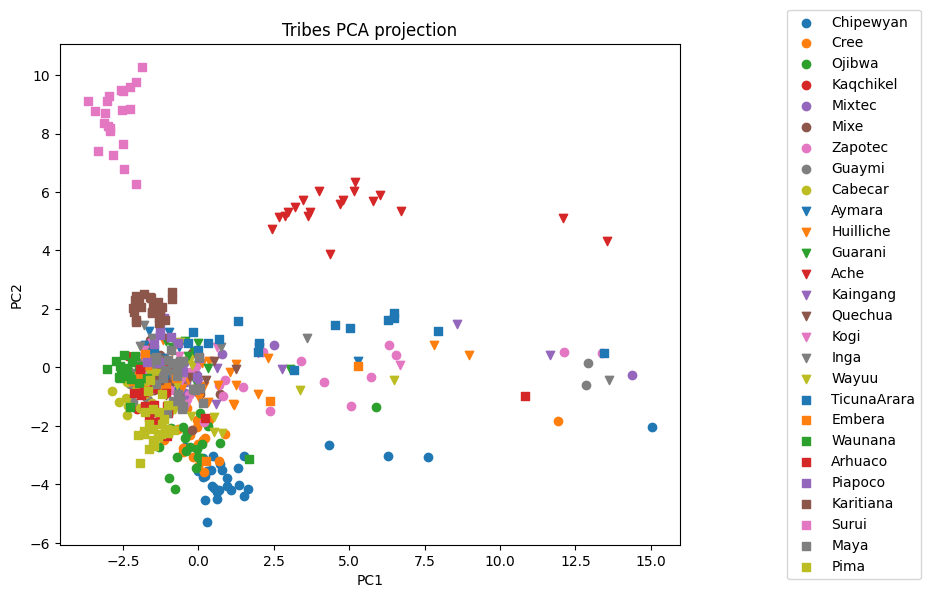

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)
Z = pca.transform(X)

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

fig, ax = plt.subplots(figsize=(8.0, 6.5))
for i, tribe in enumerate(gdf['Pop'].unique()):
    subset = Z[tribes == tribe]
    #members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(subset[:,0], subset[:,1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
    
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes PCA projection')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
fig.show()
fig.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

/tmp/ipykernel_230004/3123413209.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_230004/3123413209.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


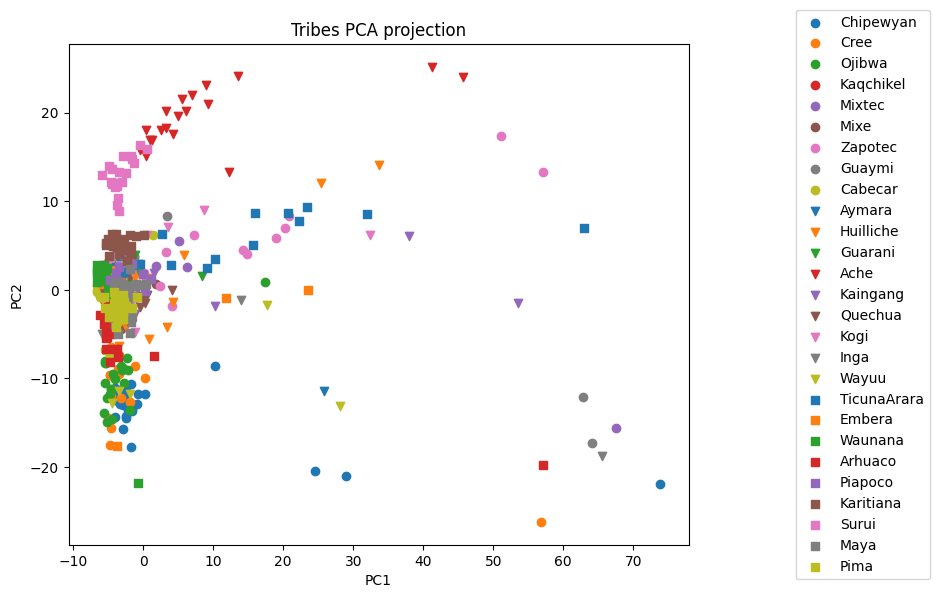

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
pca.fit(X_std)
Z_std = pca.transform(X_std)

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

fig, ax = plt.subplots(figsize=(8.0, 6.5))
for i, tribe in enumerate(gdf['Pop'].unique()):
    subset = Z_std[tribes == tribe]
    #members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(subset[:,0], subset[:,1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
    
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes PCA projection')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
fig.show()
fig.show()

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

The data seems to be less separated, so we can conclude that we should not standarize the data as we want the tribes to be more separated to classify them more easily.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X)

y = np.cumsum(pca.explained_variance_ratio_)
x = np.arange(1, len(y)+1)

plt.plot(x, y, '-')  # points + ligne
plt.xlabel("Number of components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative variance ")
plt.show()



NameError: name 'PCA' is not defined

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

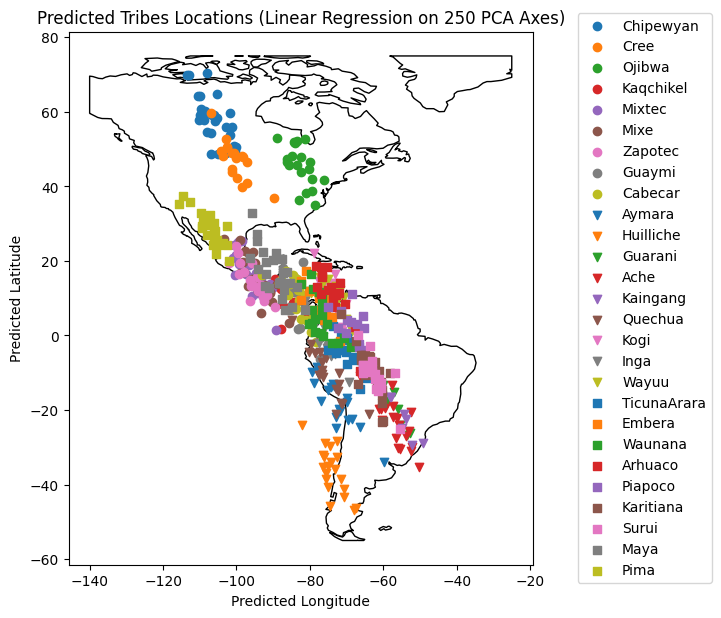

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# 1. Apply PCA to get the first 250 components
pca_250 = PCA(n_components=250)
X_pca_250 = pca_250.fit_transform(X)

# 2. Extract targets (Latitude and Longitude)
latitude = df['lat']
longitude = df['long']

# 3. Fit Linear Regression models and predict
lr_lat = LinearRegression()
lr_lat.fit(X_pca_250, latitude)
pred_lat = lr_lat.predict(X_pca_250)

lr_long = LinearRegression()
lr_long.fit(X_pca_250, longitude)
pred_long = lr_long.predict(X_pca_250)

# 4. Plot the predicted spatial coordinates 
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

# Loop over the unique tribes and plot predicted coords
for i, tribe in enumerate(df['Pop'].unique()):
    mask = (df['Pop'] == tribe)
    ax.scatter(pred_long[mask], pred_lat[mask], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Tribes Locations (Linear Regression on 250 PCA Axes)')
ax.set_xlabel('Predicted Longitude')
ax.set_ylabel('Predicted Latitude')
plt.show()


The results are very similar in both cases, with the same tribes being identified. The new map is very optimistic because we have tested the models on the same data their were trained on.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import haversine_distances

# 1. Stack latitudes and longitudes into pairs: [lat, lon]
real_coords = np.column_stack((latitude, longitude))
pred_coords = np.column_stack((pred_lat, pred_long))

# 2. Convert coordinates from degrees to radians
real_coords_rad = np.radians(real_coords)
pred_coords_rad = np.radians(pred_coords)

# 3. Calculate the NxN distance matrix between all real and predicted points
dist_matrix = haversine_distances(real_coords_rad, pred_coords_rad)

# 4. Extract the diagonal (distance between real i and predicted i)
dists_in_radians = np.diag(dist_matrix)

# 5. Multiply by Earth's radius (6371 km) to get distance in kilometers
dists_in_km = dists_in_radians * 6371.0

# 6. Calculate the mean distance in kilometers
mean_d_dist = np.mean(dists_in_km)

print(f"Mean distance error: {mean_d_dist:.2f} km")


Mean distance error: 632.33 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

Cross-validation splits our data into k subsets. Each of these subset are then used in groups of k-1 subsets to train the model, and the remaining subset is used to validate the model. This process is repeated k times, with each subset being used as the validation set once. This allows us to get an unbiased estimate of the model's performance, unlike we had in the previous example where we used a single validation set. Since our data is grouped by tribes, our datasets would not be iid and we should use group cross-validation to ensure that we don't have any tribes in the validation set that are present in the training set.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

We cannot use any of the methods that need iid data such as kfold, leave one out, etc.
There is no need to use time series here. Our data is pretty balanced between each tribe. So we can just use GroupKFold.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import haversine_distances

X = df[predictors].values
Y = np.column_stack((df['lat'], df['long']))
groups = df['Pop'].values 

# 2. Initialize GroupKFold
gkf = GroupKFold(n_splits=10)

# 3. Create the pipeline
pcr_pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=4),
    LinearRegression()
)

fold_errors = []

# 4. Perform the Cross-Validation 
for train_idx, test_idx in gkf.split(X, Y, groups=groups):
    
    # Split data into train and test folds
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    
    # Fit the entire pipeline on the train data only
    pcr_pipeline.fit(X_train, Y_train)
    
    # Predict on the test data using the fitted pipeline
    Y_pred = pcr_pipeline.predict(X_test)
    
    # --- Evaluate the error in kilometers (Haversine Distance) ---
    Y_test_rad = np.radians(Y_test)
    Y_pred_rad = np.radians(Y_pred)
    
    # Calculate Haversine distances
    dist_matrix = haversine_distances(Y_test_rad, Y_pred_rad)
    distances_km = np.diagonal(dist_matrix) * 6371.0 # Multiply by Earth's radius in km
    
    # Get the mean error for this fold
    mean_error_km = np.mean(distances_km)
    fold_errors.append(mean_error_km)

final_cv_error = np.mean(fold_errors)
print(f"Mean cross-validation error for n_components=4 : {final_cv_error:.2f} km")


Mean cross-validation error for n_components=4 : 2486.03 km


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

In [ ]:

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import haversine_distances
import matplotlib.pyplot as plt

df = pd.read_csv('NAm2.txt', delimiter=' ')
predictors = df.columns[8:]
X = df[predictors].values
Y = np.column_stack((df['lat'], df['long']))
groups = df['Pop'].values 

gkf = GroupKFold(n_splits=10)

n_components_list = range(2, 441, 10)
mean_train_errors = []
mean_test_errors = []

for n_components in n_components_list:
    pcr_pipeline = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_components),
        LinearRegression()
    )
    
    fold_train_errors = []
    fold_test_errors = []
    
    for train_idx, test_idx in gkf.split(X, Y, groups=groups):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]
        
        pcr_pipeline.fit(X_train, Y_train)
        
        # Train error
        Y_train_pred = pcr_pipeline.predict(X_train)
        Y_train_rad = np.radians(Y_train)
        Y_train_pred_rad = np.radians(Y_train_pred)
        dist_matrix_train = haversine_distances(Y_train_rad, Y_train_pred_rad)
        distances_km_train = np.diagonal(dist_matrix_train) * 6371.0
        fold_train_errors.append(np.mean(distances_km_train))
        
        # Test error
        Y_test_pred = pcr_pipeline.predict(X_test)
        Y_test_rad = np.radians(Y_test)
        Y_test_pred_rad = np.radians(Y_test_pred)
        dist_matrix_test = haversine_distances(Y_test_rad, Y_test_pred_rad)
        distances_km_test = np.diagonal(dist_matrix_test) * 6371.0
        fold_test_errors.append(np.mean(distances_km_test))
        
    mean_train_errors.append(np.mean(fold_train_errors))
    mean_test_errors.append(np.mean(fold_test_errors))

print(mean_train_errors)
print(mean_test_errors)

[np.float64(2043.3546892811835), np.float64(1420.4885525226673), np.float64(1223.193142989078), np.float64(1068.8614274954975), np.float64(940.0547296443723), np.float64(938.7065028554513), np.float64(896.4658031303428), np.float64(849.6003928300466), np.float64(826.2284873772973), np.float64(797.8858923048383), np.float64(755.8803464379505), np.float64(744.3539840747164), np.float64(700.408514258604), np.float64(686.5750966487751), np.float64(665.4021999459494), np.float64(638.3277621360277), np.float64(619.0165383247759), np.float64(599.5834429916493), np.float64(581.5776943877263), np.float64(545.8219970814789), np.float64(537.4257277717339), np.float64(518.5867393939169), np.float64(491.8697073366733), np.float64(476.55791332607015), np.float64(458.7476266156803), np.float64(435.47503325445143), np.float64(413.5150331648745), np.float64(394.16665191034065), np.float64(374.5053477878144), np.float64(354.9564590521461), np.float64(334.7574415820287), np.float64(308.6980265961197), np

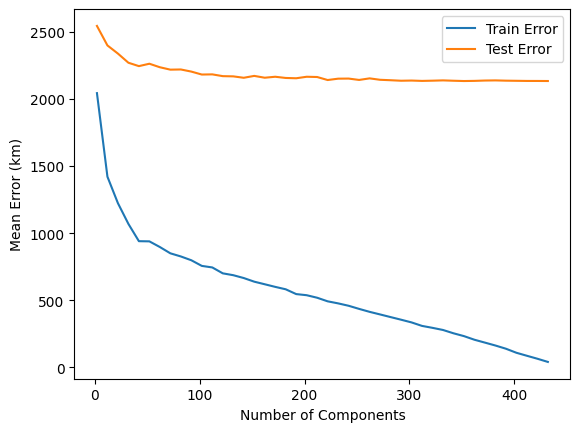

In [ ]:
plt.plot(n_components_list,mean_train_errors, label='Train Error')
plt.plot(n_components_list,mean_test_errors, label='Test Error')
plt.xlabel('Number of Components')
plt.ylabel('Mean Error (km)')
plt.legend()
plt.show()

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

I would keep the model using around 100 principal components, because after that the test error is constant while the train error decreases a lot which signals overfitting.

In [ ]:
print('train error:',mean_train_errors[10])
print('test error:',mean_test_errors[10])

train error: 755.8803464379505
test error: 2181.8304177111245


Using 102 components we get a test error around 3 times as high as the training error.

Plot successfully saved as 'predicted_coordinates_100_components.png'


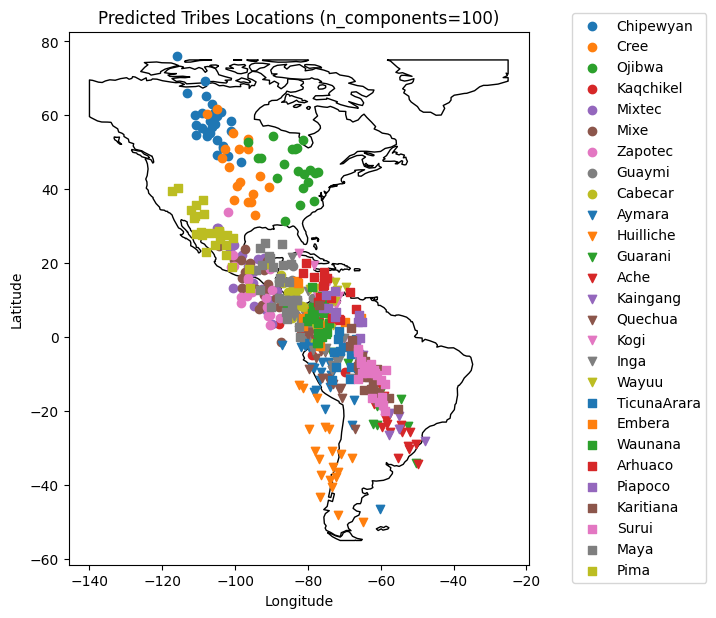

In [ ]:

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract predictors and targets
predictors = df.columns[8:]
X = df[predictors].values
Y = np.column_stack((df['lat'], df['long']))

# Fit the model with 100 components on the entire dataset
pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=100),
    LinearRegression()
)
pipeline.fit(X, Y)

# Predict the coordinates
Y_pred = pipeline.predict(X)
df['pred_lat'] = Y_pred[:, 0]
df['pred_long'] = Y_pred[:, 1]

# Create a GeoDataFrame for the predicted coordinates
gdf_pred = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['pred_long'], df['pred_lat']))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(gdf_pred['Pop'].unique()):
    members_tribe = gdf_pred[gdf_pred['Pop'] == tribe]
    ax.scatter(members_tribe['pred_long'], members_tribe['pred_lat'], 
                marker=marker_list[i//9], 
                color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Tribes Locations (n_components=100)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.savefig('predicted_coordinates_100_components.png', bbox_inches='tight')
print("Plot successfully saved as 'predicted_coordinates_100_components.png'")



## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.